## Assessment

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb

In [2]:
# ── Data ─────────────────────────────────────────────────────────────────────
df = pd.read_excel('../data/abt.xlsx')

cols_to_drop = ['floor', 'material', 'market']
X = df.drop(columns=['price_per_square_meter']).drop(columns=cols_to_drop)
y = df['price_per_square_meter']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(include='number').columns.tolist()

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# ── CV setup ─────────────────────────────────────────────────────────────────
scoring = {
    'r2':   'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae':  'neg_mean_absolute_error',
}
cv = KFold(n_splits=10, shuffle=True, random_state=42)

def cv_summary(cv_results):
    df_cv = pd.DataFrame({
        'r2':   cv_results['test_r2'],
        'rmse': -cv_results['test_rmse'],
        'mae':  -cv_results['test_mae'],
    }).agg(['mean', 'std'])
    df_cv[['rmse', 'mae']] = df_cv[['rmse', 'mae']].round(1)
    df_cv[['r2']] = df_cv[['r2']].round(4)
    return df_cv

# ── Load pipeline definitions from 04_model ──────────────────────────────────
# Pipelines are saved by 04_model.ipynb — run that notebook first to refresh them.
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
baseline       = joblib.load(MODELS_DIR / "baseline_pipeline.pkl")
dt_pipeline    = joblib.load(MODELS_DIR / "dt_pipeline.pkl")
rf_pipeline    = joblib.load(MODELS_DIR / "rf_pipeline.pkl")
xgb_pipeline   = joblib.load(MODELS_DIR / "xgb_pipeline.pkl")
lasso_pipeline = joblib.load(MODELS_DIR / "lasso_pipeline.pkl")
print("Pipelines loaded from models/")

# ── Cross-validation ─────────────────────────────────────────────────────────
print("Running 10-fold CV for all models (this may take a minute)...")
baseline_cv = cross_validate(baseline,       X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
dt_cv       = cross_validate(dt_pipeline,    X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
rf_cv       = cross_validate(rf_pipeline,    X_train, y_train, cv=cv, scoring=scoring, return_estimator=True, n_jobs=-1)
xgb_cv      = cross_validate(xgb_pipeline,   X_train, y_train, cv=cv, scoring=scoring, return_estimator=True, n_jobs=-1)
lasso_cv    = cross_validate(lasso_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
print("Done.")


Pipelines loaded from models/
Running 10-fold CV for all models (this may take a minute)...
Done.


In [3]:
# 10-fold CV comparison (mean across folds)
cv_comparison = pd.DataFrame({
    'Baseline':      cv_summary(baseline_cv).loc['mean'],
    'Decision Tree': cv_summary(dt_cv).loc['mean'],
    'Random Forest': cv_summary(rf_cv).loc['mean'],
    'XGBoost':       cv_summary(xgb_cv).loc['mean'],
    'Lasso':         cv_summary(lasso_cv).loc['mean'],
}).T
cv_comparison


,r2,rmse,mae
Baseline,-0.0017,4343.9,3280.7
Decision Tree,0.4884,3095.9,1947.5
Random Forest,0.7034,2356.9,1562.7
XGBoost,0.6946,2391.0,1622.2
Lasso,0.3730,3434.4,2470.5


# Final Test on Holdout

In [4]:
# Fit best models on full train set; evaluate on sealed holdout
holdout_results = {}
for name, pipeline in [('Random Forest', rf_pipeline), ('XGBoost', xgb_pipeline)]:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_holdout)
    holdout_results[name] = {
        'r2':   round(r2_score(y_holdout, y_pred), 4),
        'rmse': round(np.sqrt(mean_squared_error(y_holdout, y_pred)), 1),
        'mae':  round(mean_absolute_error(y_holdout, y_pred), 1),
    }

pd.DataFrame(holdout_results).T


,r2,rmse,mae
Random Forest,0.7197,2339.7,1525.7
XGBoost,0.7085,2386.4,1613.2


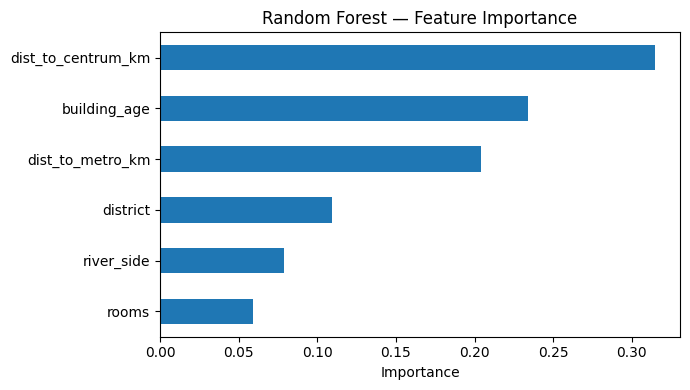

In [5]:
# Feature importance from best CV fold (RF)
best_rf = rf_cv['estimator'][np.argmax(rf_cv['test_r2'])]
feat_names = categorical_cols + numerical_cols
rf_imp = (
    pd.Series(best_rf.named_steps['model'].feature_importances_, index=feat_names)
    .sort_values()
)

rf_imp.plot(kind='barh', figsize=(7, 4))
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()


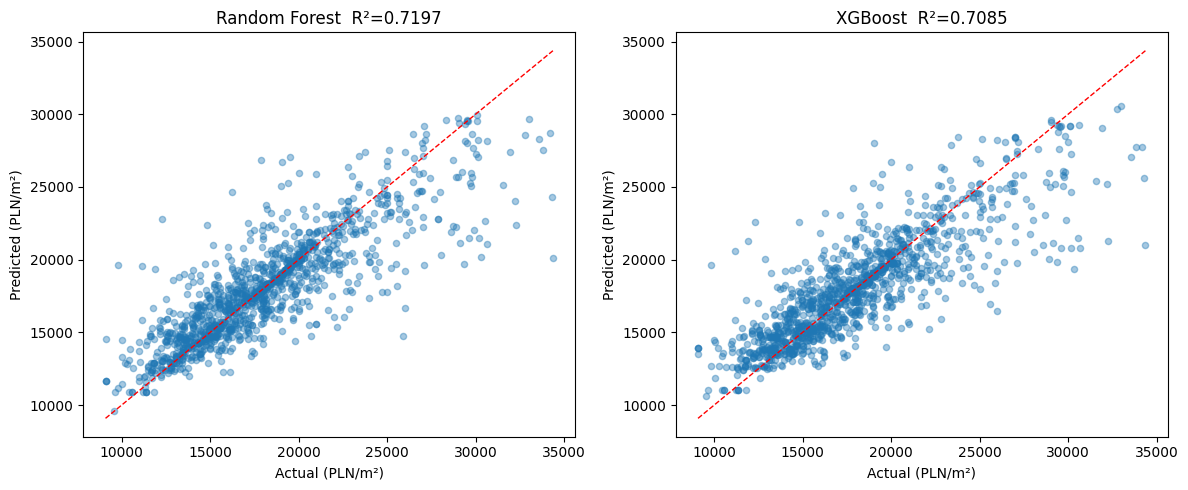

In [6]:
# Predicted vs actual — holdout set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pipeline) in zip(axes, [('Random Forest', rf_pipeline), ('XGBoost', xgb_pipeline)]):
    y_pred = pipeline.predict(X_holdout)
    lims = [min(y_holdout.min(), y_pred.min()), max(y_holdout.max(), y_pred.max())]
    ax.scatter(y_holdout, y_pred, alpha=0.4, s=20)
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('Actual (PLN/m²)')
    ax.set_ylabel('Predicted (PLN/m²)')
    ax.set_title(f'{name}  R²={r2_score(y_holdout, y_pred):.4f}')
plt.tight_layout()
plt.show()


In [7]:
import joblib
import pickle
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# Save best Random Forest pipeline
joblib.dump(rf_pipeline, MODELS_DIR / "price_model.pkl")
print("Model saved to models/price_model.pkl")

# Save the correct feature columns (matching the pipeline's expected input)
feature_cols = numerical_cols  # categorical_cols is empty; model input = numerical_cols
with open(MODELS_DIR / "feature_columns.pkl", "wb") as fh:
    pickle.dump(feature_cols, fh)
print(f"Feature columns saved: {feature_cols}")


Model saved to models/price_model.pkl
Feature columns saved: ['building_age', 'district', 'dist_to_centrum_km', 'river_side', 'rooms', 'dist_to_metro_km']


In [ ]:
app_code = r'''import pickle
import joblib
from pathlib import Path

import streamlit as st
import pandas as pd

# -- Page config ---------------------------------------------------------------
st.set_page_config(
    page_title="Warsaw Apartment Price Estimator",
    page_icon="\U0001f3e0",
    layout="centered",
)

# -- Model loading -------------------------------------------------------------
MODELS_DIR = Path(__file__).resolve().parent.parent / "models"


@st.cache_resource
def get_model():
    return joblib.load(MODELS_DIR / "price_model.pkl")


@st.cache_resource
def get_feature_columns():
    with open(MODELS_DIR / "feature_columns.pkl", "rb") as fh:
        return pickle.load(fh)


# -- District encoding ---------------------------------------------------------
# LabelEncoder used during data preparation encodes alphabetically (0-indexed).
DISTRICT_MAP = {
    "Bemowo": 0,
    "Bia\u0142o\u0142\u0119ka": 1,
    "Bielany": 2,
    "Mokot\u00f3w": 3,
    "Ochota": 4,
    "Praga Po\u0142udnie": 5,
    "Praga P\u00f3\u0142noc": 6,
    "Rembertow": 7,
    "Targ\u00f3wek": 8,
    "Ursus": 9,
    "Ursynow": 10,
    "Wawer": 11,
    "Weso\u0142a": 12,
    "Wilanow": 13,
    "Wola": 14,
    "W\u0142ochy": 15,
    "\u015ar\u00f3dmie\u015bcie": 16,
    "\u017boliborz": 17,
}

# river_side: 0 = east bank (right side), 1 = west bank (left side)
EAST_BANK = {
    "Bia\u0142o\u0142\u0119ka",
    "Praga Po\u0142udnie",
    "Praga P\u00f3\u0142noc",
    "Rembertow",
    "Targ\u00f3wek",
    "Wawer",
    "Weso\u0142a",
}


def river_side_for(district_name):
    return 0 if district_name in EAST_BANK else 1


# -- UI ------------------------------------------------------------------------
st.title("\U0001f3e0 Warsaw Apartment Price Estimator")
st.caption(
    "Predict the price per m\u00b2 (PLN) using a Random Forest model "
    "trained on Warsaw real-estate listings."
)
st.divider()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Property details")
    rooms = st.number_input("Number of rooms", min_value=1, max_value=10, value=3, step=1)
    construction_year = st.number_input(
        "Year of construction", min_value=1900, max_value=2030, value=2000, step=1
    )
    current_year = pd.Timestamp.now().year
    building_age = current_year - construction_year

with col2:
    st.subheader("Location")
    district_name = st.selectbox("District", options=sorted(DISTRICT_MAP.keys()))
    dist_to_metro_km = st.number_input(
        "Distance to metro (km)", min_value=0.0, max_value=50.0, value=1.0, step=0.1, format="%.2f"
    )
    dist_to_centrum_km = st.number_input(
        "Distance to city centre (km)", min_value=0.0, max_value=50.0, value=5.0, step=0.1, format="%.2f"
    )

st.divider()

# -- Derived features ----------------------------------------------------------
district_code = DISTRICT_MAP[district_name]
river_side_code = river_side_for(district_name)
bank_label = (
    "East bank (right side of Vistula)"
    if river_side_code == 0
    else "West bank (left side of Vistula)"
)

with st.expander("Derived values used by the model", expanded=False):
    st.markdown(
        f"""
        | Feature | Value |
        |---|---|
        | Building age | **{building_age}** years |
        | District code | **{district_code}** |
        | River side | **{river_side_code}** ({bank_label}) |
        """
    )

# -- Prediction ----------------------------------------------------------------
if st.button("Estimate price per m\u00b2", type="primary", use_container_width=True):
    model = get_model()
    feature_columns = get_feature_columns()

    input_dict = {
        "building_age": building_age,
        "district": district_code,
        "dist_to_centrum_km": dist_to_centrum_km,
        "river_side": river_side_code,
        "rooms": rooms,
        "dist_to_metro_km": dist_to_metro_km,
    }

    input_df = pd.DataFrame([input_dict]).reindex(columns=feature_columns)

    try:
        price_per_m2 = model.predict(input_df)[0]
        st.success(f"### Estimated price: **{price_per_m2:,.0f} PLN / m\u00b2**")
    except Exception as e:
        st.error(f"Prediction error: {e}")
'''

app_path = Path("../app/estimate_app.py")
app_path.write_text(app_code, encoding="utf-8")
print(f"Written {len(app_code)} chars to {app_path.resolve()}")


Written 4083 chars to C:\Users\klimanska.n\warsaw_real_estate_market\app\estimate_app.py
